# 03 — Baseline classification

## Objective

Build and evaluate initial models that predict a CROME cell's 2025 land-use class using information available in 2024.

The models will be compared with a simple majority-class baseline. Training and test observations will be separated geographically to provide a more realistic evaluation.

In [3]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [4]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

prepared_data_path = (
    project_root
    / "data"
    / "interim"
    / "crome_prepared_data.gpkg"
)

data = gpd.read_file(
    prepared_data_path,
    layer="prepared_data"
)

print("Data shape:", data.shape)
print("CRS:", data.crs)

data.head()

Data shape: (4868, 9)
CRS: EPSG:4326


,cromeid,lucode_2024,land_use_2024,confidence_2024,easting,northing,target_2025,target_name_2025,geometry
0,RPA512626340510,PG01,Grass,0.320,512626.778605,340512.123903,AC66,Winter Wheat,"POLYGON ((-0.32484 52.94986, -0.32544 52.94987..."
1,RPA513046344216,AC66,Winter Wheat,0.297,513046.696018,344218.716060,AC66,Winter Wheat,"POLYGON ((-0.31699 52.98339, -0.3173 52.98308,..."
2,RPA512026344112,AC66,Winter Wheat,0.577,512026.721345,344114.825388,AC03,Beet,"POLYGON ((-0.33312 52.98237, -0.33341 52.98268..."
3,RPA512386340579,FA01,Fallow Land,0.182,512386.762061,340581.398936,AC66,Winter Wheat,"POLYGON ((-0.32808 52.95084, -0.32839 52.95054..."
4,RPA513286341168,AC66,Winter Wheat,0.462,513286.771223,341170.282658,LG20,Winter Field beans,"POLYGON ((-0.31479 52.95564, -0.31539 52.95565..."


In [5]:
print("Expected file:", prepared_data_path)
print("File exists:", prepared_data_path.exists())

Expected file: /Users/dafyddjones/projects/lincolnshire-crop-prediction/data/interim/crome_prepared_data.gpkg
File exists: True


In [6]:
print("File exists:", prepared_data_path.exists())

File exists: True


In [7]:
feature_columns = [
    "lucode_2024",
    "confidence_2024",
    "easting",
    "northing"
]

target_column = "target_2025"

split_easting = data["easting"].quantile(0.80)

train_mask = data["easting"] <= split_easting
test_mask = data["easting"] > split_easting

X_train = data.loc[
    train_mask,
    feature_columns
].copy()

X_test = data.loc[
    test_mask,
    feature_columns
].copy()

y_train = data.loc[
    train_mask,
    target_column
].copy()

y_test = data.loc[
    test_mask,
    target_column
].copy()

print("Split easting:", round(split_easting, 2))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training classes:", y_train.nunique())
print("Test classes:", y_test.nunique())

Split easting: 513646.7
Training rows: 3894
Test rows: 974
Training classes: 13
Test classes: 13


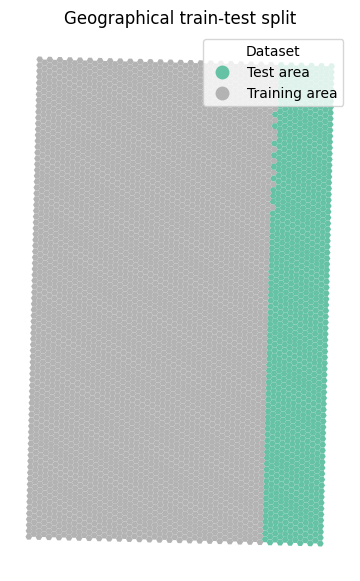

In [8]:
split_map = data[["geometry"]].copy()

split_map["dataset"] = "Training area"

split_map.loc[
    test_mask,
    "dataset"
] = "Test area"

fig, ax = plt.subplots(
    figsize=(8, 7)
)

split_map.plot(
    column="dataset",
    categorical=True,
    legend=True,
    cmap="Set2",
    linewidth=0,
    ax=ax,
    legend_kwds={
        "title": "Dataset"
    }
)

ax.set_title(
    "Geographical train-test split"
)

ax.set_axis_off()

plt.show()

## 3. Majority-class baseline

The dummy classifier always predicts the most common class in the training data. It provides a minimum benchmark that genuine models should outperform.

In [9]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train,
    y_train
)

dummy_predictions = dummy_model.predict(
    X_test
)

target_name_map = (
    data[
        ["target_2025", "target_name_2025"]
    ]
    .drop_duplicates()
    .set_index("target_2025")[
        "target_name_2025"
    ]
    .to_dict()
)

dummy_class = dummy_predictions[0]

dummy_accuracy = accuracy_score(
    y_test,
    dummy_predictions
)

dummy_balanced_accuracy = balanced_accuracy_score(
    y_test,
    dummy_predictions
)

dummy_macro_f1 = f1_score(
    y_test,
    dummy_predictions,
    average="macro",
    zero_division=0
)

print(
    "Predicted class:",
    dummy_class,
    "-",
    target_name_map[dummy_class]
)

print(
    "Accuracy:",
    round(dummy_accuracy, 3)
)

print(
    "Balanced accuracy:",
    round(dummy_balanced_accuracy, 3)
)

print(
    "Macro F1:",
    round(dummy_macro_f1, 3)
)

Predicted class: AC66 - Winter Wheat
Accuracy: 0.478
Balanced accuracy: 0.077
Macro F1: 0.05


## 4. Logistic regression

Logistic regression provides the first genuine predictive model. The categorical land-use code is one-hot encoded, while the numerical predictors are standardised.

Balanced class weights are used so that uncommon categories contribute more fairly during training.

In [10]:
categorical_features = [
    "lucode_2024"
]

numerical_features = [
    "confidence_2024",
    "easting",
    "northing"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2_000,
                class_weight="balanced"
            )
        )
    ]
)

In [11]:
logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        logistic_predictions
    )
)

logistic_macro_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

print(
    "Accuracy:",
    round(logistic_accuracy, 3)
)

print(
    "Balanced accuracy:",
    round(logistic_balanced_accuracy, 3)
)

print(
    "Macro F1:",
    round(logistic_macro_f1, 3)
)

Accuracy: 0.394
Balanced accuracy: 0.285
Macro F1: 0.251


## 5. Class-level performance

Overall metrics can hide large differences between land-use categories. Precision, recall and F1 score are therefore calculated separately for each target class.

In [12]:
class_codes = sorted(
    y_test.unique()
)

report_data = classification_report(
    y_test,
    logistic_predictions,
    labels=class_codes,
    output_dict=True,
    zero_division=0
)

class_report = (
    pd.DataFrame(report_data)
    .transpose()
    .loc[
        class_codes,
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
)

class_report.insert(
    0,
    "land_use",
    [
        target_name_map[code]
        for code in class_codes
    ]
)

class_report["support"] = (
    class_report["support"].astype(int)
)

class_report = class_report.sort_values(
    "f1-score",
    ascending=False
)

class_report.round(3)

,land_use,precision,recall,f1-score,support
NA01,Non-vegetated or sparsely-vegetated Land,0.832,0.827,0.830,156
PG01,Grass,0.678,0.833,0.748,48
AC66,Winter Wheat,0.770,0.345,0.477,466
WO12,"Trees and Scrubs, short Woody plants, hedgerows",0.383,0.600,0.468,30
CA02,Cover Crop,0.526,0.211,0.301,95
AC67,Winter Oilseed,0.152,0.389,0.219,18
OTHER,Other rare land uses,0.120,0.103,0.111,29
AC03,Beet,0.039,0.222,0.067,18
AC17,Maize,0.017,0.091,0.028,11
LG20,Winter Field beans,0.005,0.083,0.009,12


In [13]:
class_report.tail(8).round(3)

,land_use,precision,recall,f1-score,support
AC67,Winter Oilseed,0.152,0.389,0.219,18
OTHER,Other rare land uses,0.120,0.103,0.111,29
AC03,Beet,0.039,0.222,0.067,18
AC17,Maize,0.017,0.091,0.028,11
LG20,Winter Field beans,0.005,0.083,0.009,12
AC01,Spring Barley,0.000,0.000,0.000,12
AC63,Winter Barley,0.000,0.000,0.000,28
FA01,Fallow Land,0.000,0.000,0.000,51


### Logistic regression findings

Logistic regression recognised Non-vegetated Land and Grass particularly well. It also produced relatively precise Winter Wheat predictions, although it missed many actual wheat cells.

Performance was poor for several less common crops. Spring Barley, Winter Barley and Fallow Land had no correct predictions in the test area.

The model improves substantially on the dummy classifier's balanced accuracy and macro F1 score, but the results show that the relationship between 2024 and 2025 land use is too complex for this linear model and the current predictors alone.

## 6. K-nearest neighbours

K-nearest neighbours predicts each test cell from the classifications of similar training cells. Numerical features are standardised so that geographical coordinates do not dominate the distance calculation.

In [14]:
from sklearn.base import clone
from sklearn.neighbors import KNeighborsClassifier

In [15]:
knn_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=15,
                weights="distance"
            )
        )
    ]
)

knn_model.fit(
    X_train,
    y_train
)

knn_predictions = knn_model.predict(
    X_test
)

In [16]:
knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

knn_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        knn_predictions
    )
)

knn_macro_f1 = f1_score(
    y_test,
    knn_predictions,
    average="macro",
    zero_division=0
)

print(
    "Accuracy:",
    round(knn_accuracy, 3)
)

print(
    "Balanced accuracy:",
    round(knn_balanced_accuracy, 3)
)

print(
    "Macro F1:",
    round(knn_macro_f1, 3)
)

Accuracy: 0.648
Balanced accuracy: 0.248
Macro F1: 0.245


### KNN findings

K-nearest neighbours achieved 64.8% accuracy, substantially outperforming both the majority-class baseline and logistic regression on overall accuracy.

Its balanced accuracy and macro F1 were slightly below logistic regression, indicating that the improvement was concentrated among the more common land-use classes. KNN therefore provides stronger overall predictions but does not solve the difficulty of identifying uncommon crops.

## 7. Random forest

Random forest combines many decision trees. Each tree learns different rules from the training data, and their combined vote produces the final prediction.

Class balancing and minimum leaf sizes are used to reduce bias towards common classes and limit overfitting.

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = (
    random_forest_model.predict(
        X_test
    )
)

In [19]:
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        random_forest_predictions
    )
)

random_forest_macro_f1 = f1_score(
    y_test,
    random_forest_predictions,
    average="macro",
    zero_division=0
)

print(
    "Accuracy:",
    round(random_forest_accuracy, 3)
)

print(
    "Balanced accuracy:",
    round(
        random_forest_balanced_accuracy,
        3
    )
)

print(
    "Macro F1:",
    round(random_forest_macro_f1, 3)
)

Accuracy: 0.599
Balanced accuracy: 0.355
Macro F1: 0.307


In [20]:
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic regression",
        "KNN",
        "Random forest"
    ],
    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy,
        knn_accuracy,
        random_forest_accuracy
    ],
    "Balanced accuracy": [
        dummy_balanced_accuracy,
        logistic_balanced_accuracy,
        knn_balanced_accuracy,
        random_forest_balanced_accuracy
    ],
    "Macro F1": [
        dummy_macro_f1,
        logistic_macro_f1,
        knn_macro_f1,
        random_forest_macro_f1
    ]
})

model_comparison = (
    model_comparison
    .set_index("Model")
)

(
    model_comparison
    .mul(100)
    .round(1)
)

,Accuracy,Balanced accuracy,Macro F1
Model,,,
Dummy,47.8,7.7,5.0
Logistic regression,39.4,28.5,25.1
KNN,64.8,24.8,24.5
Random forest,59.9,35.5,30.7


## 8. Model comparison

The models are compared using overall accuracy and two metrics that give greater importance to performance across all land-use classes.

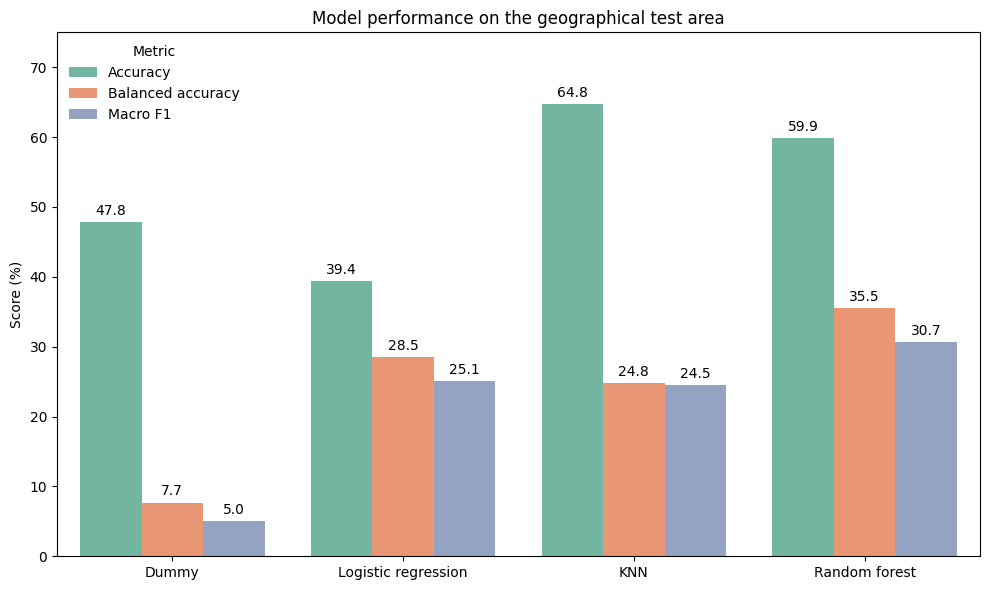

In [21]:
comparison_plot_data = (
    model_comparison
    .mul(100)
    .reset_index()
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

sns.barplot(
    data=comparison_plot_data,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3
    )

ax.set_title(
    "Model performance on the geographical test area"
)

ax.set_xlabel("")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 75)

ax.legend(
    title="Metric",
    frameon=False
)

plt.tight_layout()
plt.show()

In [22]:
random_forest_report_data = classification_report(
    y_test,
    random_forest_predictions,
    labels=class_codes,
    output_dict=True,
    zero_division=0
)

random_forest_class_report = (
    pd.DataFrame(
        random_forest_report_data
    )
    .transpose()
    .loc[
        class_codes,
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
)

random_forest_class_report.insert(
    0,
    "land_use",
    [
        target_name_map[code]
        for code in class_codes
    ]
)

random_forest_class_report["support"] = (
    random_forest_class_report[
        "support"
    ].astype(int)
)

random_forest_class_report = (
    random_forest_class_report
    .sort_values(
        "f1-score",
        ascending=False
    )
)

random_forest_class_report.round(3)

,land_use,precision,recall,f1-score,support
PG01,Grass,0.812,0.812,0.812,48
NA01,Non-vegetated or sparsely-vegetated Land,0.814,0.731,0.770,156
AC66,Winter Wheat,0.759,0.749,0.754,466
AC67,Winter Oilseed,0.269,1.000,0.424,18
WO12,"Trees and Scrubs, short Woody plants, hedgerows",0.300,0.600,0.400,30
CA02,Cover Crop,0.467,0.295,0.361,95
FA01,Fallow Land,0.500,0.216,0.301,51
AC63,Winter Barley,0.083,0.143,0.105,28
OTHER,Other rare land uses,0.050,0.069,0.058,29
AC01,Spring Barley,0.000,0.000,0.000,12


### Random forest findings

Random forest produced strong results for Grass, Non-vegetated Land and Winter Wheat, with F1 scores between 75% and 81%.

It identified every Winter Oilseed cell, but its low precision shows that it also incorrectly labelled many other cells as Winter Oilseed.

Performance improved for Fallow Land compared with logistic regression. However, Spring Barley, Beet, Maize and Winter Field Beans had no correct predictions.

Random forest provides the strongest balanced performance overall, but further feature engineering would be required to predict the less common crops reliably.

## 9. Feature importance

Feature importance estimates how strongly each predictor contributed to the random forest's decisions. It describes predictive influence, not causation.

In [23]:
fitted_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

fitted_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

transformed_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": (
        fitted_classifier.feature_importances_
    )
})

feature_importance[
    "importance_percentage"
] = (
    feature_importance["importance"]
    * 100
)

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance[
    [
        "feature",
        "importance_percentage"
    ]
].head(15).round(2)

,feature,importance_percentage
0,numerical__northing,28.70
1,numerical__easting,24.65
2,numerical__confidence_2024,19.34
3,categorical__lucode_2024_WO12,5.41
4,categorical__lucode_2024_NA01,5.14
5,categorical__lucode_2024_PG01,4.71
6,categorical__lucode_2024_AC66,3.43
7,categorical__lucode_2024_AC32,1.54
8,categorical__lucode_2024_AC01,1.39
9,categorical__lucode_2024_AC17,1.21


### Feature-importance findings

Geographical location was the strongest influence on the random forest. Easting and northing contributed approximately 53% of total feature importance, while the 2024 confidence score contributed approximately 19%.

The most influential previous land-use categories included Trees and Scrubs, Non-vegetated Land, Grass and Winter Wheat.

This suggests that agricultural classifications are strongly spatially clustered within the study area. It also means that the model may not generalise equally well to other parts of Lincolnshire, so geographical validation remains important.

Feature importance measures predictive influence and should not be interpreted as evidence of causation.

## Conclusion

Four classification models were evaluated using a geographically separate test area containing 974 cells.

The dummy classifier achieved 47.8% accuracy but recognised only Winter Wheat. Logistic regression improved performance across the different classes but had lower overall accuracy.

K-nearest neighbours achieved the highest accuracy at 64.8%. Random forest achieved 59.9% accuracy and produced the strongest balanced accuracy and macro F1 scores, making it the preferred model when performance across all land-use categories is considered.

The models predicted Grass, Non-vegetated Land and Winter Wheat most successfully. Several uncommon crops remained difficult to identify.

Location was the strongest source of predictive information. Future improvements could include neighbouring-cell features, spatial cross-validation, model tuning and additional years of CROME data.